# Predicting Titanic Survival with Decision Trees
Goal:
- Predict whether Titantic passengers survived the shipwreck using a decision tree
- Determine first split by calculating entropy and information gain to understand the mathematics behind decision trees
- Build and optimize the full decision tree using the scikit-learn library

## Import libraries and data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math
titanic = pd.read_csv('/content/drive/MyDrive/ML/Titanic.csv')

titanic.head()

,Unnamed: 0,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1st,yes,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.337494,B5,Southampton,2,NaN,"St Louis, MO"
1,2,1st,yes,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.550003,C22 C26,Southampton,11,NaN,"Montreal, PQ / Chesterville, ON"
2,3,1st,no,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,4,1st,no,"Allison, Mr. Hudson Joshua Crei",male,30.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,5,1st,no,"Allison, Mrs. Hudson J C (Bessi",female,25.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Data preprocessing
Impute missing data, encode categorical data, split age into bins.

In [ ]:
#impute mean age for missing age values
titanic['age'] = titanic['age'].fillna(titanic['age'].mean())

#subset data to only includes columns we will use
titanic = titanic[['pclass','sex','age','sibsp','survived']]

#convert survived column to to binary
titanic['survived'] = titanic['survived'].apply(lambda x: 1 if x == 'yes' else 0)

#convert pclass to integer class numbers
# Check if 'pclass' is of object type (string-like) before applying string operations
import pandas as pd
if pd.api.types.is_object_dtype(titanic['pclass']):
    titanic['pclass'] = titanic['pclass'].apply(lambda x: int(x[0]))

#convert sex column to integer (MALE = 1, FEMALE = 0)
titanic['sex'] = titanic['sex'].apply(lambda x: 1 if x == 'male' else 0)

#use qcut to group age into 10 bins
titanic['age'] = pd.qcut(titanic['age'], 10, labels=False, duplicates='drop')

#80-20 train-test split
X = titanic.drop('survived', axis=1)
y = titanic['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(titanic.head())

   pclass  sex  age  sibsp  survived
0       1    0    4      0         1
1       1    1    0      1         1
2       1    0    0      1         0
3       1    1    5      1         0
4       1    0    3      1         0


## Use entropy and information gain formulas to determine first split
Sex had the highest information gain due to the priorization of women during evacuation operations

In [ ]:
#create function that calculates entropy for a specific attribute of a feature
def entropy(df, feature, attribute, target):
    #calculate rate where target = 1 for given attribute
    target_1_rate = len(df[(df[feature] == attribute) & (df[target] == 1)]) / len(df[df[feature] == attribute])
    #calculate entropy
    if target_1_rate == 0 or target_1_rate == 1:
        return 0
    else:
        return -target_1_rate * math.log2(target_1_rate) - (1 - target_1_rate) * math.log2(1 - target_1_rate)

#create information gain function for first split
def info_gain(df, feature, target):
  #calculate parent entropy (original entropy of survival data)
  target_1_rate = len(df[df[target] == 1]) / len(df)
  parent_entropy = -target_1_rate * math.log2(target_1_rate) - (1 - target_1_rate) * math.log2(1 - target_1_rate)
  #atttributes array
  attributes = df[feature].unique()
  #attribute weight array
  attribute_weights = [len(df[df[feature] == attribute]) / len(df) for attribute in attributes]
  #attribute entorpy array
  attribute_entropies = [entropy(df, feature, attribute, target) for attribute in attributes]
  #calculate info gain
  info_gain = parent_entropy - sum([attribute_weights[i] * attribute_entropies[i] for i in range(len(attributes))])
  return info_gain

#print info gain for each feature
for feature in titanic.columns[:-1]:
    print(f"Information gain for {feature}: {info_gain(titanic, feature, 'survived')}")


Information gain for pclass: 0.0704074128460409
Information gain for sex: 0.20550487272007611
Information gain for age: 0.018607530828718133
Information gain for sibsp: 0.026983534163970258


## Use scikit-learn decision tree package to train, display, and evaluate model

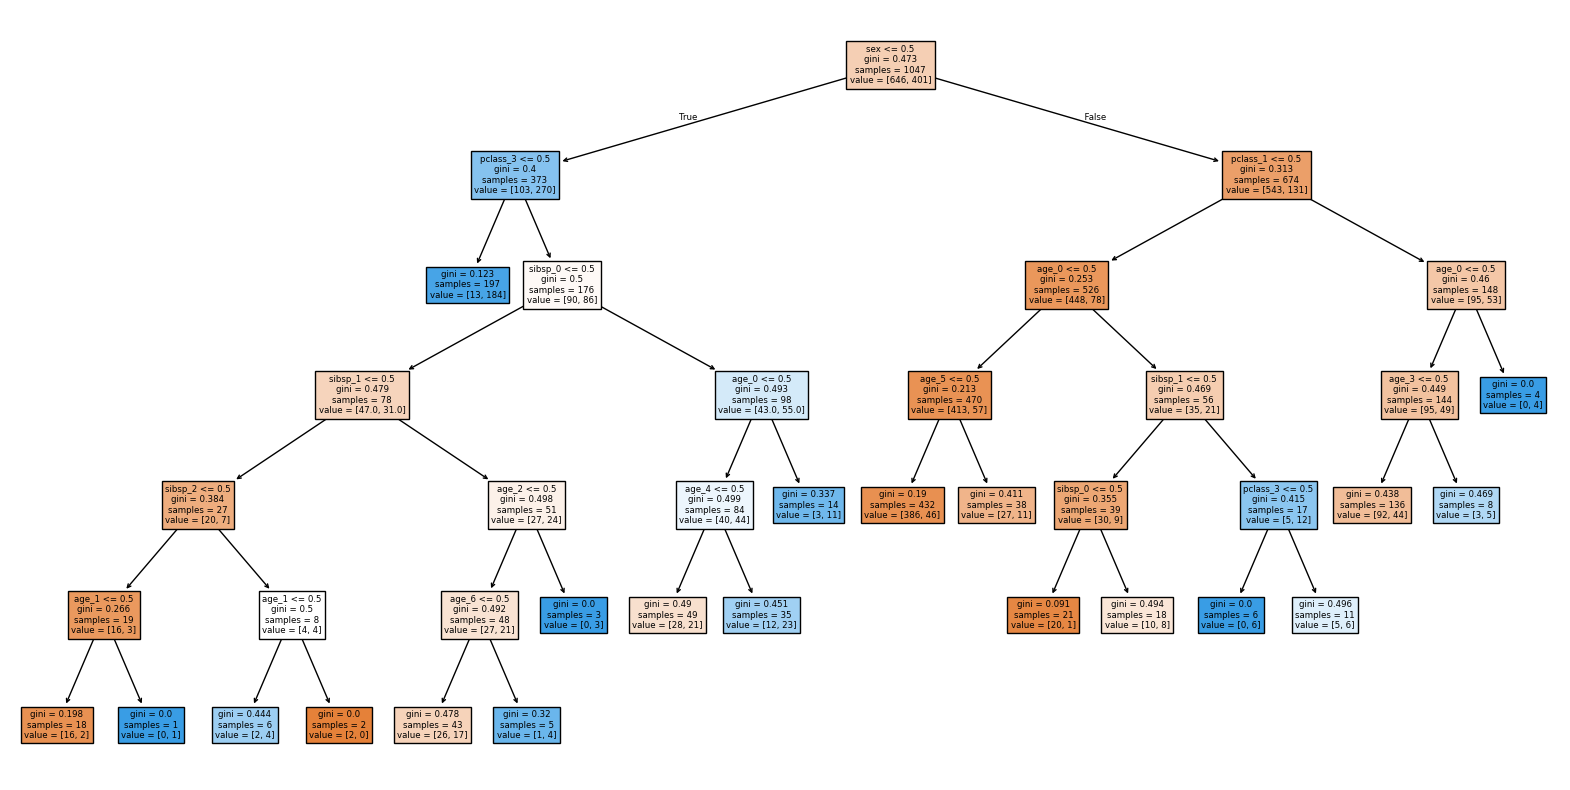

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import plot_tree

#one-hot encode features with more than 2 values
ohe = OneHotEncoder(handle_unknown='ignore')
#determine which features do and don't need encoding
features_to_encode = ['pclass', 'age', 'sibsp']
non_encoded_features = ['sex']
#fit one-hot encoder and convert to dataframe
encoded_features = ohe.fit_transform(X[features_to_encode])
encoded_cols = ohe.get_feature_names_out(features_to_encode)
encoded_features = pd.DataFrame(encoded_features.toarray(), columns=encoded_cols, index=X.index)
#create new X with newly encoded features and original non-encoded features
X = pd.concat([encoded_features, X[non_encoded_features]], axis=1)
#split data into 80/20 train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
#create decision tree classifier with maximum leaf nodes of 20
clf = DecisionTreeClassifier(max_leaf_nodes=20, random_state=20045079)
#train model
clf.fit(X_train, y_train)
#plot the tree
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=X.columns)
plt.show()

In [ ]:
#create metrics function to calculate accuracy, precision, recall, and F1 score
def metrics(y_pred, y_test):
  #get a count of TP, TN, FP, FN
  TP = sum((y_pred == 1) & (y_test == 1))
  TN = sum((y_pred == 0) & (y_test == 0))
  FP = sum((y_pred == 1) & (y_test == 0))
  FN = sum((y_pred == 0) & (y_test == 1))
  total_count = len(y_test)
  #calculate accuracy
  accuracy = (TP + TN) / total_count
  #calculate precision
  precision = TP / (TP + FP)
  #calculate recall
  recall = TP / (TP + FN)
  #calculate F1 score
  f1 = 2 * (precision * recall) / (precision + recall)
  #print metrics
  print(f"Accuracy: {accuracy}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1 Score: {f1}")

#make predictions on test data
y_pred = clf.predict(X_test)
#output metrics
metrics(y_pred, y_test)


Accuracy: 0.7938931297709924
Precision: 0.8169014084507042
Recall: 0.5858585858585859
F1 Score: 0.6823529411764706


## Conduct a grid search to find optimal number of maximum leaf nodes
Not enough leaf nodes will lead to a weaker model, while too many will lead to overfitting. Optimal max_leaf_nodes in this case was 24, which slightly improved model performance.

Optimal max leaf nodes: 24


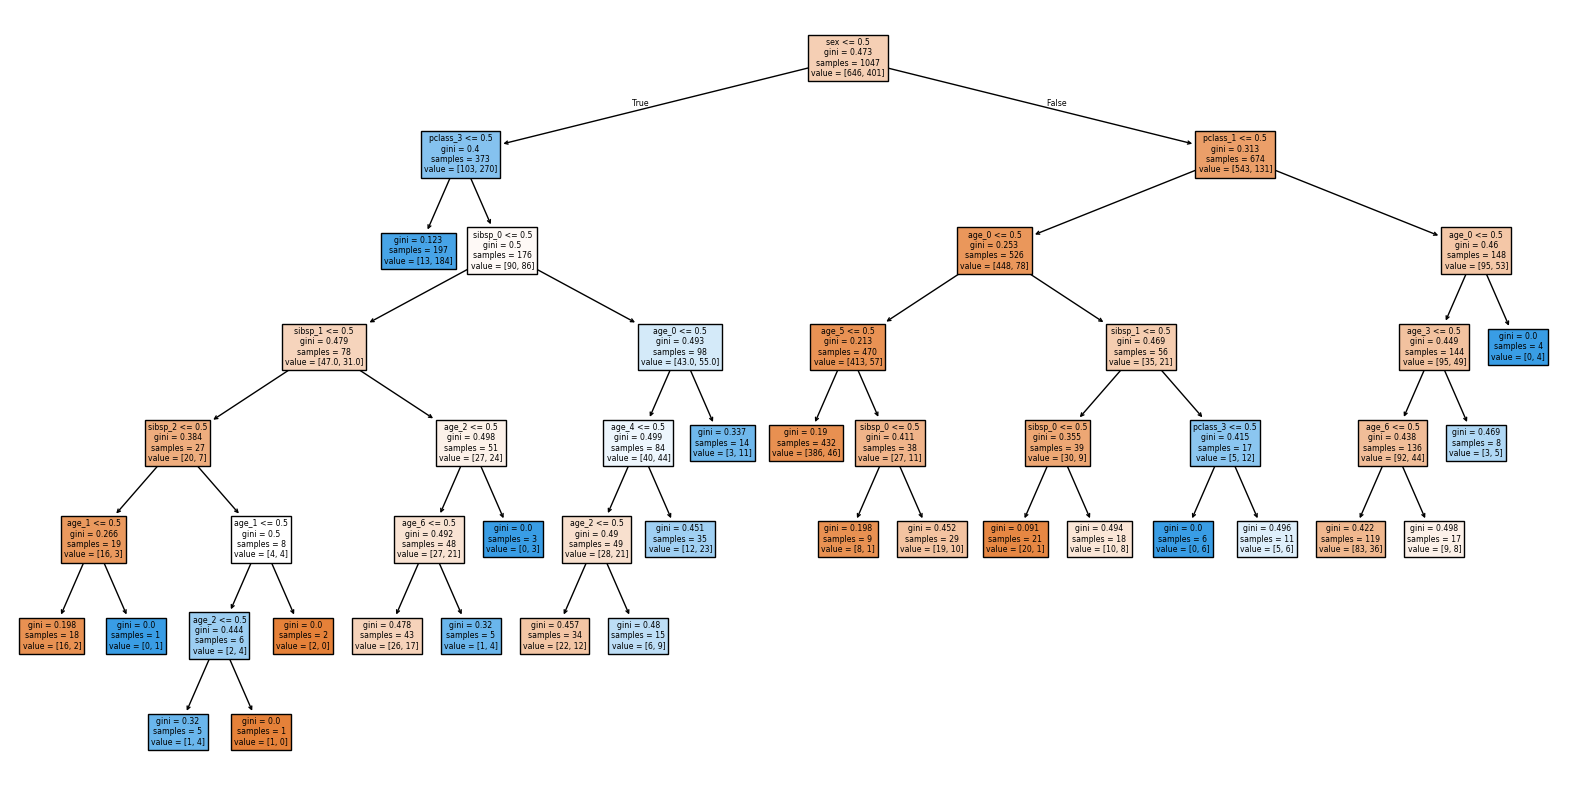

Accuracy: 0.8015267175572519
Precision: 0.8133333333333334
Recall: 0.6161616161616161
F1 Score: 0.7011494252873564


In [ ]:
from sklearn.model_selection import GridSearchCV

#identify optimal max leaf nodes using 5-fold cross validaiton
param_grid = {'max_leaf_nodes': range(5, 31)}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=20045079), param_grid, cv=5)
grid_search.fit(X_train, y_train)

#store optimal max leaf nodes
optimal_max_leaf_nodes = grid_search.best_params_['max_leaf_nodes']

#print determined optimal max leaf nodes
print(f"Optimal max leaf nodes: {optimal_max_leaf_nodes}")

#predict with optimized tree model
clf_optimized = DecisionTreeClassifier(max_leaf_nodes=optimal_max_leaf_nodes, random_state=20045079)
clf_optimized.fit(X_train, y_train)
y_pred_optimized = clf_optimized.predict(X_test)

#plot the tree
plt.figure(figsize=(20,10))
plot_tree(clf_optimized, filled=True, feature_names=X.columns)
plt.show()

#print metrics
metrics(y_pred_optimized, y_test)
